# 02_modelling_1 — Pair Screener

Generates `cache/pairs_screened.parquet` and `cache/all_pairs_stats.parquet`.

**Input:** `cache/prices.parquet`, `cache/sectors.parquet` (from `01_data.ipynb`)

**Output:** `cache/pairs_screened.parquet` : consumed by `02_modelling_2.ipynb`

## 1. Imports & Setup

In [2]:
import warnings
import itertools
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

print("All imports successful.")

All imports successful.


In [3]:
CACHE_DIR = Path("cache")

prices  = pd.read_parquet(CACHE_DIR / "prices.parquet")
sectors        = pd.read_parquet(CACHE_DIR / "sectors.parquet")["sector"]
sub_industries = pd.read_parquet(CACHE_DIR / "sectors.parquet")["sub_industry"]

print(f"prices  : {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"sectors : {len(sectors)} tickers across {sectors.nunique()} sectors")
print(f"Date range: {prices.index[0].date()} -> {prices.index[-1].date()}")

# GICS sub-industry -> industry mapping (level 3 of 4, 74 categories)
_GICS_MAP = {
    "Integrated Oil & Gas": "Oil, Gas & Consumable Fuels",
    "Oil & Gas Exploration & Production": "Oil, Gas & Consumable Fuels",
    "Oil & Gas Refining & Marketing": "Oil, Gas & Consumable Fuels",
    "Oil & Gas Storage & Transportation": "Oil, Gas & Consumable Fuels",
    "Coal & Consumable Fuels": "Oil, Gas & Consumable Fuels",
    "Oil & Gas Equipment & Services": "Energy Equipment & Services",
    "Commodity Chemicals": "Chemicals",
    "Diversified Chemicals": "Chemicals",
    "Fertilizers & Agricultural Chemicals": "Chemicals",
    "Industrial Gases": "Chemicals",
    "Specialty Chemicals": "Chemicals",
    "Construction Materials": "Construction Materials",
    "Metal & Glass Containers": "Containers & Packaging",
    "Paper Packaging": "Containers & Packaging",
    "Aluminum": "Metals & Mining",
    "Diversified Metals & Mining": "Metals & Mining",
    "Gold": "Metals & Mining",
    "Precious Metals & Minerals": "Metals & Mining",
    "Steel": "Metals & Mining",
    "Forest Products": "Paper & Forest Products",
    "Paper Products": "Paper & Forest Products",
    "Aerospace & Defense": "Aerospace & Defense",
    "Building Products": "Building Products",
    "Construction & Engineering": "Construction & Engineering",
    "Electrical Components & Equipment": "Electrical Equipment",
    "Heavy Electrical Equipment": "Electrical Equipment",
    "Industrial Conglomerates": "Industrial Conglomerates",
    "Construction Machinery & Heavy Transportation Equipment": "Machinery",
    "Agricultural & Farm Machinery": "Machinery",
    "Industrial Machinery & Supplies & Components": "Machinery",
    "Trading Companies & Distributors": "Trading Companies & Distributors",
    "Commercial Printing": "Commercial & Professional Services",
    "Environmental & Facilities Services": "Commercial & Professional Services",
    "Office Services & Supplies": "Commercial & Professional Services",
    "Diversified Support Services": "Commercial & Professional Services",
    "Human Resource & Employment Services": "Commercial & Professional Services",
    "Research & Consulting Services": "Professional Services",
    "Air Freight & Logistics": "Air Freight & Logistics",
    "Airlines": "Passenger Airlines",
    "Marine Transportation": "Marine Transportation",
    "Passenger Ground Transportation": "Ground Transportation",
    "Cargo Ground Transportation": "Ground Transportation",
    "Rail Transportation": "Ground Transportation",
    "Airport Services": "Transportation Infrastructure",
    "Highways & Railtracks": "Transportation Infrastructure",
    "Marine Ports & Services": "Transportation Infrastructure",
    "Automobile Manufacturers": "Automobiles",
    "Motorcycle Manufacturers": "Automobiles",
    "Automotive Parts & Equipment": "Auto Components",
    "Tires & Rubber": "Auto Components",
    "Consumer Electronics": "Household Durables",
    "Home Furnishings": "Household Durables",
    "Homebuilding": "Household Durables",
    "Household Appliances": "Household Durables",
    "Housewares & Specialties": "Household Durables",
    "Leisure Products": "Leisure Products",
    "Apparel, Accessories & Luxury Goods": "Textiles, Apparel & Luxury Goods",
    "Footwear": "Textiles, Apparel & Luxury Goods",
    "Textiles": "Textiles, Apparel & Luxury Goods",
    "Casinos & Gaming": "Hotels, Restaurants & Leisure",
    "Hotels, Resorts & Cruise Lines": "Hotels, Restaurants & Leisure",
    "Leisure Facilities": "Hotels, Restaurants & Leisure",
    "Restaurants": "Hotels, Restaurants & Leisure",
    "Education Services": "Diversified Consumer Services",
    "Specialized Consumer Services": "Diversified Consumer Services",
    "Distributors": "Distributors",
    "Internet & Direct Marketing Retail": "Broadline Retail",
    "Department Stores": "Broadline Retail",
    "General Merchandise Stores": "Broadline Retail",
    "Broadline Retail": "Broadline Retail",
    "Apparel Retail": "Specialty Retail",
    "Automotive Retail": "Specialty Retail",
    "Computer & Electronics Retail": "Specialty Retail",
    "Home Improvement Retail": "Specialty Retail",
    "Other Specialty Retail": "Specialty Retail",
    "Specialty Stores": "Specialty Retail",
    "Drug Retail": "Consumer Staples Distribution & Retail",
    "Food Distributors": "Consumer Staples Distribution & Retail",
    "Food Retail": "Consumer Staples Distribution & Retail",
    "Hypermarkets & Super Centers": "Consumer Staples Distribution & Retail",
    "Consumer Staples Distribution & Retail": "Consumer Staples Distribution & Retail",
    "Brewers": "Beverages",
    "Distillers & Vintners": "Beverages",
    "Soft Drinks & Non-alcoholic Beverages": "Beverages",
    "Agricultural Products & Services": "Food Products",
    "Packaged Foods & Meats": "Food Products",
    "Tobacco": "Tobacco",
    "Household Products": "Household Products",
    "Personal Care Products": "Personal Care Products",
    "Health Care Equipment": "Health Care Equipment & Supplies",
    "Health Care Supplies": "Health Care Equipment & Supplies",
    "Health Care Distributors": "Health Care Providers & Services",
    "Health Care Facilities": "Health Care Providers & Services",
    "Health Care Services": "Health Care Providers & Services",
    "Managed Health Care": "Health Care Providers & Services",
    "Health Care Technology": "Health Care Technology",
    "Biotechnology": "Biotechnology",
    "Pharmaceuticals": "Pharmaceuticals",
    "Life Sciences Tools & Services": "Life Sciences Tools & Services",
    "Diversified Banks": "Banks",
    "Regional Banks": "Banks",
    "Diversified Financial Services": "Financial Services",
    "Multi-Sector Holdings": "Financial Services",
    "Specialized Finance": "Financial Services",
    "Consumer Finance": "Consumer Finance",
    "Asset Management & Custody Banks": "Capital Markets",
    "Investment Banking & Brokerage": "Capital Markets",
    "Diversified Capital Markets": "Capital Markets",
    "Financial Exchanges & Data": "Capital Markets",
    "Mortgage REITs": "Mortgage Real Estate Investment Trusts",
    "Insurance Brokers": "Insurance",
    "Life & Health Insurance": "Insurance",
    "Multi-line Insurance": "Insurance",
    "Property & Casualty Insurance": "Insurance",
    "Reinsurance": "Insurance",
    "IT Consulting & Other Services": "IT Services",
    "Data Processing & Outsourced Services": "IT Services",
    "Internet Services & Infrastructure": "IT Services",
    "Application Software": "Software",
    "Systems Software": "Software",
    "Technology Hardware, Storage & Peripherals": "Technology Hardware, Storage & Peripherals",
    "Electronic Components": "Electronic Equipment, Instruments & Components",
    "Electronic Equipment & Instruments": "Electronic Equipment, Instruments & Components",
    "Electronic Manufacturing Services": "Electronic Equipment, Instruments & Components",
    "Semiconductor Materials & Equipment": "Semiconductors & Semiconductor Equipment",
    "Semiconductors": "Semiconductors & Semiconductor Equipment",
    "Alternative Carriers": "Diversified Telecommunication Services",
    "Integrated Telecommunication Services": "Diversified Telecommunication Services",
    "Wireless Telecommunication Services": "Wireless Telecommunication Services",
    "Advertising": "Media",
    "Broadcasting": "Media",
    "Cable & Satellite": "Media",
    "Movies & Entertainment": "Entertainment",
    "Interactive Home Entertainment": "Entertainment",
    "Interactive Media & Services": "Interactive Media & Services",
    "Electric Utilities": "Electric Utilities",
    "Gas Utilities": "Gas Utilities",
    "Multi-Utilities": "Multi-Utilities",
    "Water Utilities": "Water Utilities",
    "Independent Power Producers & Energy Traders": "Independent Power and Renewable Electricity Producers",
    "Renewable Electricity": "Independent Power and Renewable Electricity Producers",
    "Diversified REITs": "Diversified REITs",
    "Industrial REITs": "Industrial REITs",
    "Hotel & Resort REITs": "Hotel & Resort REITs",
    "Office REITs": "Office REITs",
    "Health Care REITs": "Health Care REITs",
    "Residential REITs": "Residential REITs",
    "Retail REITs": "Retail REITs",
    "Specialized REITs": "Specialized REITs",
    "Real Estate Management & Development": "Real Estate Management & Development",
}
industries = sub_industries.map(_GICS_MAP)
unmapped = industries.isna().sum()
if unmapped:
    print(f'Warning: {unmapped} tickers have unmapped sub-industries: '
          f'{sub_industries[industries.isna()].unique().tolist()}')

prices  : 4132 days x 262 tickers
sectors : 262 tickers across 11 sectors
Date range: 2010-01-04 -> 2026-06-08


In [ ]:
# Save industry mapping to cache so 03_strategy.ipynb can load it directly
# without needing to reduplicate the _GICS_MAP dict
industries.to_frame("industry").to_parquet(CACHE_DIR / "industries.parquet")
print(f"Saved industries.parquet: {industries.notna().sum()} tickers across {industries.nunique()} industries")

---
## 1 - Pair Screener

### 1.1 Generate within-sector candidate pairs

In [4]:
def generate_candidate_pairs(sectors: pd.Series) -> list:
    pairs = []
    for sector, group in sectors.groupby(sectors):
        tickers = group.index.tolist()
        for t1, t2 in itertools.combinations(tickers, 2):
            pairs.append((t1, t2, sector))
    return pairs


candidate_pairs = generate_candidate_pairs(sectors)

pair_df_preview = pd.DataFrame(candidate_pairs, columns=["ticker_1", "ticker_2", "sector"])
print(f"Total candidate pairs : {len(candidate_pairs):,}")
print()
print("Pairs per sector:")
print(pair_df_preview.groupby("sector").size().sort_values(ascending=False).to_string())

Total candidate pairs : 3,087

Pairs per sector:
sector
Consumer Staples          378
Utilities                 378
Real Estate               378
Health Care               351
Industrials               325
Financials                276
Consumer Discretionary    276
Materials                 253
Information Technology    231
Communication Services    136
Energy                    105


### 1.2 Engle-Granger cointegration test

Tests whether OLS residuals from Y~X (and X~Y) are stationary via ADF.
A pair passes if either direction has p-value < 5%.

In [4]:
def engle_granger_test(s1: pd.Series, s2: pd.Series, pvalue_threshold: float = 0.05) -> dict:
    df = pd.concat([s1, s2], axis=1).dropna()
    if len(df) < 252:
        return {"passed": False, "pvalue": np.nan, "hedge_ratio": np.nan}

    y1, x1 = df.iloc[:, 0].values, df.iloc[:, 1].values
    y2, x2 = df.iloc[:, 1].values, df.iloc[:, 0].values

    score1, pval1, _ = coint(y1, x1)
    score2, pval2, _ = coint(y2, x2)

    best_pval = min(pval1, pval2)
    passed    = best_pval < pvalue_threshold

    if pval1 <= pval2:
        hedge_ratio = np.polyfit(x1, y1, 1)[0]
    else:
        hedge_ratio = 1.0 / np.polyfit(x2, y2, 1)[0]

    return {"passed": passed, "pvalue": best_pval, "hedge_ratio": hedge_ratio}


# Quick test: pick two Financials tickers actually present in prices
fin_tickers = [t for t in sectors[sectors == "Financials"].index if t in prices.columns]
T1_TEST, T2_TEST = fin_tickers[0], fin_tickers[1]

eg_result = engle_granger_test(prices[T1_TEST].dropna(), prices[T2_TEST].dropna())
print(f"{T1_TEST} / {T2_TEST}  ->  passed: {eg_result['passed']}  "
      f"|  p-value: {eg_result['pvalue']:.4f}  "
      f"|  hedge ratio: {eg_result['hedge_ratio']:.4f}")

ACGL / AFL  ->  passed: False  |  p-value: 0.2481  |  hedge ratio: 0.9605


### 1.3 Johansen cointegration test

VAR-based test using trace statistic vs 95% critical value.
More powerful than EG; tests both series symmetrically.

In [5]:
def johansen_test(s1: pd.Series, s2: pd.Series, pvalue_threshold: float = 0.05) -> dict:
    df = pd.concat([s1, s2], axis=1).dropna()
    if len(df) < 252:
        return {"passed": False, "trace_stat": np.nan, "crit_value_95": np.nan}

    try:
        result = coint_johansen(df.values, det_order=0, k_ar_diff=1)
        trace_stat  = result.lr1[0]
        crit_val_95 = result.cvt[0, 1]
        passed      = trace_stat > crit_val_95
        return {"passed": passed, "trace_stat": trace_stat, "crit_value_95": crit_val_95}
    except Exception:
        return {"passed": False, "trace_stat": np.nan, "crit_value_95": np.nan}


joh_result = johansen_test(prices[T1_TEST].dropna(), prices[T2_TEST].dropna())
print(f"{T1_TEST} / {T2_TEST}  ->  passed: {joh_result['passed']}  "
      f"|  trace stat: {joh_result['trace_stat']:.4f}  "
      f"|  95% crit: {joh_result['crit_value_95']:.4f}")

ACGL / AFL  ->  passed: False  |  trace stat: 11.0686  |  95% crit: 15.4943


### 1.4 OU Half-Life Filter

Estimate mean-reversion speed from spread regression: ΔS_t = a + b·S_{t-1} + ε

Half-life = −ln(2) / b  (in trading days). Filter: 5 ≤ half-life ≤ 100.

In [6]:
def compute_halflife(spread: pd.Series) -> float:
    spread = spread.dropna()
    lag    = spread.shift(1).dropna()
    delta  = spread.diff().dropna()

    lag   = lag.iloc[:len(delta)]
    delta = delta.iloc[:len(lag)]

    b = np.polyfit(lag.values, delta.values, 1)[0]
    if b >= 0:
        return np.inf
    return -np.log(2) / b


spread_test = prices[T1_TEST] - eg_result["hedge_ratio"] * prices[T2_TEST]
hl = compute_halflife(spread_test)
print(f"{T1_TEST} / {T2_TEST}  ->  half-life: {hl:.1f} trading days")

ACGL / AFL  ->  half-life: 136.0 trading days


### 1.5 Run the full screening pipeline

Three-priority load logic:
- **Priority 1**: `pairs_screened.parquet` exists → load instantly
- **Priority 2**: `all_pairs_stats.parquet` exists → re-filter with new thresholds
- **Priority 3**: neither exists → compute from scratch (~30 min)

In [ ]:
# Screening configuration — tweak these and re-run filter_pairs() only
EG_PVALUE_THRESHOLD  = 0.05
JOH_PVALUE_THRESHOLD = 0.05
MIN_HALFLIFE         = 5
MAX_HALFLIFE         = 100

ALL_PAIRS_CACHE      = CACHE_DIR / "all_pairs_stats.parquet"
PAIRS_SCREENED_CACHE = CACHE_DIR / "pairs_screened.parquet"


def compute_all_pair_stats(candidate_pairs: list, prices: pd.DataFrame) -> pd.DataFrame:
    records = []
    n = len(candidate_pairs)
    log.info(f"Computing stats for {n:,} pairs (runs once, then cached)...")

    for i, (t1, t2, sector) in enumerate(candidate_pairs):
        if i % 500 == 0 and i > 0:
            log.info(f"  {i:,}/{n:,} done...")
        if t1 not in prices.columns or t2 not in prices.columns:
            continue
        s1 = prices[t1].dropna()
        s2 = prices[t2].dropna()
        common = s1.index.intersection(s2.index)
        if len(common) < 252:
            continue
        s1, s2 = s1[common], s2[common]

        eg   = engle_granger_test(s1, s2)
        joh  = johansen_test(s1, s2)
        hl   = compute_halflife(s1 - eg["hedge_ratio"] * s2)
        corr = s1.corr(s2)

        records.append({
            "ticker_1"      : t1,
            "ticker_2"      : t2,
            "sector"        : sector,
            "eg_pvalue"     : eg["pvalue"],
            "eg_hedge_ratio": eg["hedge_ratio"],
            "eg_passed"     : eg["passed"],
            "joh_trace_stat": joh["trace_stat"],
            "joh_crit_95"   : joh["crit_value_95"],
            "joh_passed"    : joh["passed"],
            "halflife"      : hl,
            "price_corr"    : corr,
        })

    df = pd.DataFrame(records)
    log.info(f"Done — {len(df):,} pairs with sufficient history.")
    return df


def filter_pairs(
    all_stats      : pd.DataFrame,
    prices         : pd.DataFrame,
    industries     : pd.Series,
    eg_threshold   : float = EG_PVALUE_THRESHOLD,
    joh_threshold  : float = JOH_PVALUE_THRESHOLD,
    min_hl         : float = MIN_HALFLIFE,
    max_hl         : float = MAX_HALFLIFE,
    min_corr       : float = 0.70,
) -> pd.DataFrame:
    n  = len(all_stats)
    df = all_stats[all_stats["eg_pvalue"] < eg_threshold].copy();  n_eg  = len(df)
    df = df[df["joh_passed"]].copy();                               n_joh = len(df)
    df = df[df["halflife"].between(min_hl, max_hl)].copy();         n_hl  = len(df)

    # Industry filter (GICS level 3 — same industry required)
    df["same_industry"] = df.apply(
        lambda r: industries.get(r["ticker_1"]) == industries.get(r["ticker_2"]),
        axis=1,
    )
    df = df[df["same_industry"]].copy();  n_sub = len(df)

    # Price correlation filter
    if "price_corr" not in df.columns:
        df["price_corr"] = df.apply(
            lambda r: prices[r["ticker_1"]].corr(prices[r["ticker_2"]]), axis=1
        )
    df = df[df["price_corr"] >= min_corr].copy();  n_corr = len(df)

    print("\n-- SCREENING FUNNEL -----------------------------------------------")
    print(f"Candidate pairs       : {n:>6,}")
    print(f"After Engle-Granger   : {n_eg:>6,}  ({n_eg/n*100:.1f}%)")
    print(f"After Johansen        : {n_joh:>6,}  ({n_joh/n*100:.1f}%)")
    print(f"After half-life filter: {n_hl:>6,}  ({n_hl/n*100:.1f}%)")
    print(f"After industry filter : {n_sub:>6,}  ({n_sub/n*100:.1f}%)")
    print(f"After correlation     : {n_corr:>6,}  ({n_corr/n*100:.1f}%)")
    print("-------------------------------------------------------------------\n")
    return df.reset_index(drop=True)


# Invalidate old cache if it pre-dates the new filters
if PAIRS_SCREENED_CACHE.exists():
    _tmp = pd.read_parquet(PAIRS_SCREENED_CACHE)
    if "price_corr" not in _tmp.columns or "same_industry" not in _tmp.columns:
        PAIRS_SCREENED_CACHE.unlink()
        log.info("Invalidated stale pairs_screened cache (missing new filter columns).")

# Priority 1: load pairs_screened directly (fastest)
if PAIRS_SCREENED_CACHE.exists():
    pairs_screened = pd.read_parquet(PAIRS_SCREENED_CACHE)
    log.info(f"Loaded pairs_screened from cache: {len(pairs_screened)} pairs.")

# Priority 2: load all-pair stats and re-filter
elif ALL_PAIRS_CACHE.exists():
    log.info("Loading all-pairs stats and applying filters...")
    all_pairs_stats = pd.read_parquet(ALL_PAIRS_CACHE)
    pairs_screened  = filter_pairs(all_pairs_stats, prices=prices, industries=industries)
    pairs_screened.to_parquet(PAIRS_SCREENED_CACHE)
    log.info(f"Saved pairs_screened to {PAIRS_SCREENED_CACHE}.")

# Priority 3: compute from scratch
else:
    log.info("No cache found — running full pipeline (this takes ~30 min)...")
    all_pairs_stats = compute_all_pair_stats(candidate_pairs, prices)
    all_pairs_stats.to_parquet(ALL_PAIRS_CACHE)
    pairs_screened  = filter_pairs(all_pairs_stats, prices=prices, industries=industries)
    pairs_screened.to_parquet(PAIRS_SCREENED_CACHE)

print(f"Surviving pairs: {len(pairs_screened)}")
pairs_screened.head(10)

### 1.6 Screening results

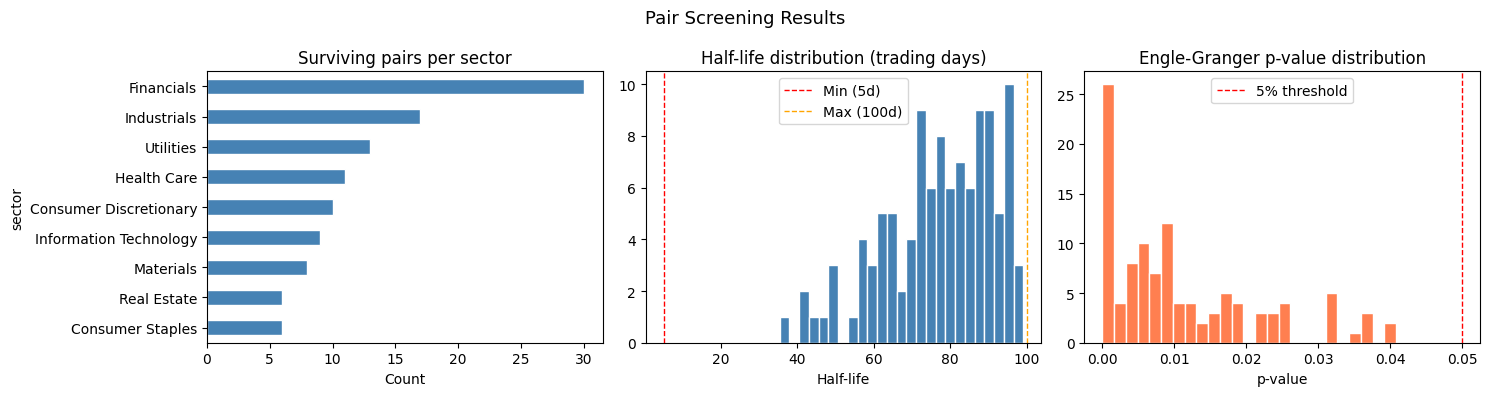

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pair Screening Results", fontsize=13)

pairs_screened.groupby("sector").size().sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Surviving pairs per sector")
axes[0].set_xlabel("Count")

axes[1].hist(pairs_screened["halflife"], bins=25, color="steelblue", edgecolor="white")
axes[1].axvline(MIN_HALFLIFE, color="red",    linestyle="--", linewidth=1,
                label=f"Min ({MIN_HALFLIFE}d)")
axes[1].axvline(MAX_HALFLIFE, color="orange", linestyle="--", linewidth=1,
                label=f"Max ({MAX_HALFLIFE}d)")
axes[1].set_title("Half-life distribution (trading days)")
axes[1].set_xlabel("Half-life")
axes[1].legend()

axes[2].hist(pairs_screened["eg_pvalue"], bins=25, color="coral", edgecolor="white")
axes[2].axvline(0.05, color="red", linestyle="--", linewidth=1, label="5% threshold")
axes[2].set_title("Engle-Granger p-value distribution")
axes[2].set_xlabel("p-value")
axes[2].legend()

plt.tight_layout()
plt.savefig(CACHE_DIR / "screening_results.png", dpi=130, bbox_inches="tight")
plt.show()